# c2-activity · Modelo, consulta y limpieza de datos
**Cristhian Gaitán Guzmán** · Ciencia de Datos (Cód. 69109) · CORHUILA 2026-B · Semana 9 (Corte 2)

Cuaderno **ejecutado** con las tres partes de la actividad: (1) base de datos que implementa el ERD, (2) limpieza con pandas con reporte antes/después (con figuras de respaldo) y (3) dos preguntas con consultas SQL y pandas, más un análisis de sensibilidad de las decisiones de limpieza. El ERD (Mermaid) y la sección *Data & cleaning* en inglés están en el `README.md`.

**Caso:** planta de empaques del Huila (4 máquinas, 2 líneas, 3 turnos). Pregunta de negocio: *¿qué máquina y qué turno concentran los defectos, y a cuál le hacemos mantenimiento primero?* Dataset ilustrativo del taller de la Semana 9 [2], no datos reales de una empresa.

> Para ejecutarlo, abre el cuaderno desde la carpeta `c2-activity/` (necesita `data/registro_produccion.csv` y `schema.sql`).

In [1]:
import re, sqlite3
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

BASE = Path.cwd()                      # carpeta c2-activity/
DATA = BASE / "data"
MAQUINAS_VALIDAS = ["M-01", "M-02", "M-03", "M-04"]
TURNOS_VALIDOS = ["Mañana", "Tarde", "Noche"]
CAPACIDAD_MAX = 1800                   # unidades por turno
SENSOR_MIN, SENSOR_MAX = 15, 60        # °C
print("pandas", pd.__version__)

pandas 3.0.2


## 1. Carga y diagnóstico inicial (antes de tocar nada)
El archivo original **no se modifica**: toda la limpieza se hace sobre una copia.

In [2]:
df = pd.read_csv(DATA / "registro_produccion.csv")
print("Filas y columnas:", df.shape)
display(df.sample(8, random_state=7))
print(df.dtypes.to_string())
print("\nNulos por columna:")
print(df.isna().sum().to_string())
print("\nFilas duplicadas:", df.duplicated().sum())
print("Valores distintos en 'maquina':", df["maquina"].nunique(), "(esperado 4)")
print("Valores distintos en 'turno'  :", df["turno"].nunique(), "(esperado 3)")
con_barra = df["fecha"].str.contains("/")
temp_num = pd.to_numeric(df["temperatura"], errors="coerce")
coma_decimal = temp_num.isna() & df["temperatura"].notna()
print("Fechas dd/mm/aaaa:", con_barra.sum(), "| temperaturas con coma decimal:", coma_decimal.sum(),
      "| lecturas > 60 (°F):", (temp_num > 60).sum())

Filas y columnas: (297, 6)


,fecha,turno,maquina,producidas,defectuosas,temperatura
199,2026-09-25,MAÑANA,M-04,1276,14.0,30.7
3,2026-09-07,Mañana,M-04,1054,18.0,31.2
216,26/09/2026,Tarde,M-04,1034,17.0,31.3
284,03/10/2026,Mañana,M-02,1107,21.0,30.7
125,2026-09-18,Mañana,M-04,1126,11.0,30.5
243,2026-09-29,Noche,M-01,18,1295.0,32.2
78,2026-09-14,Tarde,M-01,1069,8.0,34.2
99,2026-09-16,Mañana,M-02,1177,27.0,88.0


fecha              str
turno              str
maquina            str
producidas       int64
defectuosas    float64
temperatura        str

Nulos por columna:
fecha           0
turno           0
maquina         0
producidas      0
defectuosas    10
temperatura     6

Filas duplicadas: 9
Valores distintos en 'maquina': 16 (esperado 4)
Valores distintos en 'turno'  : 12 (esperado 3)
Fechas dd/mm/aaaa: 30 | temperaturas con coma decimal: 20 | lecturas > 60 (°F): 14


### Funciones de medición
Se usan **antes y después**, de modo que la comparación mide exactamente lo mismo. Las cinco dimensiones: completitud, unicidad, consistencia, formato y validez [6].

In [3]:
def reporte_calidad(tabla):
    """% de filas que cumple cada dimensión de calidad."""
    prod = pd.to_numeric(tabla["producidas"], errors="coerce")
    defe = pd.to_numeric(tabla["defectuosas"], errors="coerce")
    temp = pd.to_numeric(tabla["temperatura"], errors="coerce")
    cumple_reglas = (prod.between(1, CAPACIDAD_MAX) & defe.between(0, prod)
                     & temp.between(SENSOR_MIN, SENSOR_MAX))
    medidas = {
        "Completitud": tabla.notna().all(axis=1).mean(),
        "Unicidad": (~tabla.duplicated()).mean(),
        "Consistencia": (tabla["maquina"].isin(MAQUINAS_VALIDAS) & tabla["turno"].isin(TURNOS_VALIDOS)).mean(),
        "Formato": tabla["fecha"].astype(str).str.fullmatch(r"\d{4}-\d{2}-\d{2}").mean(),
        "Validez": cumple_reglas.mean(),
    }
    return (pd.Series(medidas) * 100).round(1)


def perfil(tabla):
    temp_texto = pd.api.types.is_string_dtype(tabla["temperatura"]) or tabla["temperatura"].dtype == object
    return {
        "Filas": len(tabla),
        "Celdas vacías (nulos)": int(tabla.isna().sum().sum()),
        "Filas con algún vacío": int(tabla.isna().any(axis=1).sum()),
        "Filas duplicadas": int(tabla.duplicated().sum()),
        "Valores distintos en 'maquina' (esperado 4)": int(tabla["maquina"].nunique()),
        "Valores distintos en 'turno' (esperado 3)": int(tabla["turno"].nunique()),
        "Fechas fuera de aaaa-mm-dd": int((~tabla["fecha"].astype(str).str.fullmatch(r"\d{4}-\d{2}-\d{2}")).sum()),
        "Tipo de 'temperatura'": "texto" if temp_texto else "numérico",
        "Tipo de 'fecha'": "fecha" if pd.api.types.is_datetime64_any_dtype(tabla["fecha"]) else "texto",
    }


bitacora = []
def registrar(paso, accion, antes, despues, corregidos=0):
    bitacora.append({"paso": paso, "accion": accion, "filas_antes": antes, "filas_despues": despues,
                     "filas_eliminadas": antes - despues, "valores_corregidos": corregidos})
    print(f"[{paso}] {accion:<52} filas {antes} -> {despues} | corregidos: {corregidos}")


calidad_antes, perfil_antes = reporte_calidad(df), perfil(df)
calidad_antes

Completitud     94.6
Unicidad        97.0
Consistencia    88.9
Formato         89.9
Validez         80.8
dtype: float64

## 2. Limpieza paso a paso (siempre sobre una copia)
**Paso 1 · Duplicados** (unicidad) y **Paso 2 · textos inconsistentes** (consistencia): se quitan las copias exactas y se homologan los códigos de máquina y turno con un diccionario.

In [4]:
limpio = df.copy()

# Paso 1 · duplicados
antes = len(limpio)
limpio = limpio.drop_duplicates().reset_index(drop=True)
registrar("Paso 1", "Quitar filas duplicadas", antes, len(limpio))

# Paso 2 · homologar textos
maq_orig, tur_orig = limpio["maquina"].copy(), limpio["turno"].copy()
limpio["maquina"] = limpio["maquina"].str.strip().str.upper()
limpio["maquina"] = limpio["maquina"].replace({
    "M01": "M-01", "M02": "M-02", "M03": "M-03", "M04": "M-04",
    "M-1": "M-01", "M-2": "M-02", "M-3": "M-03", "M-4": "M-04"})
limpio["turno"] = limpio["turno"].str.strip().str.capitalize().replace({"Manana": "Mañana"})
cambios_texto = int((limpio["maquina"] != maq_orig).sum() + (limpio["turno"] != tur_orig).sum())
registrar("Paso 2", "Homologar máquinas y turnos", len(limpio), len(limpio), cambios_texto)
assert limpio.duplicated().sum() == 0, "Aparecieron duplicados nuevos al homologar"
print("Máquinas:", sorted(limpio["maquina"].unique()), "| Turnos:", sorted(limpio["turno"].unique()))

[Paso 1] Quitar filas duplicadas                              filas 297 -> 288 | corregidos: 0
[Paso 2] Homologar máquinas y turnos                          filas 288 -> 288 | corregidos: 33
Máquinas: ['M-01', 'M-02', 'M-03', 'M-04'] | Turnos: ['Mañana', 'Noche', 'Tarde']


**Paso 3 · Tipos y formatos.** La temperatura venía como texto por la coma decimal; las fechas mezclaban `aaaa-mm-dd` y `dd/mm/aaaa`. Se convierte formato por formato (adivinar `07/09` es peligroso: ¿7 de septiembre o 9 de julio?) y se verifica que la conversión no vacíe datos.

**Paso 4 · Unidades.** Ninguna máquina trabaja a 95 °C: todo valor sobre 60 °C está en Fahrenheit.

In [5]:
# Paso 3 · tipos
vacios_antes = int(limpio["temperatura"].isna().sum())
limpio["temperatura"] = pd.to_numeric(
    limpio["temperatura"].astype(str).str.replace(",", ".", regex=False), errors="coerce")
assert int(limpio["temperatura"].isna().sum()) == vacios_antes, "to_numeric vació datos válidos"

iso = pd.to_datetime(limpio["fecha"], format="%Y-%m-%d", errors="coerce")
dmy = pd.to_datetime(limpio["fecha"], format="%d/%m/%Y", errors="coerce")
limpio["fecha"] = iso.fillna(dmy)
assert limpio["fecha"].isna().sum() == 0, "Quedaron fechas sin convertir"
registrar("Paso 3", "Temperatura a número y fechas a un solo formato",
          len(limpio), len(limpio), int(coma_decimal.sum() + con_barra.sum()))
print("Rango de fechas:", limpio["fecha"].min().date(), "a", limpio["fecha"].max().date())

# Paso 4 · °F -> °C
en_f = limpio["temperatura"] > SENSOR_MAX
limpio.loc[en_f, "temperatura"] = ((limpio.loc[en_f, "temperatura"] - 32) * 5 / 9).round(1)
registrar("Paso 4", "Convertir lecturas en °F a °C", len(limpio), len(limpio), int(en_f.sum()))

[Paso 3] Temperatura a número y fechas a un solo formato      filas 288 -> 288 | corregidos: 50
Rango de fechas: 2026-09-07 a 2026-10-03
[Paso 4] Convertir lecturas en °F a °C                        filas 288 -> 288 | corregidos: 14


**Paso 5 · Faltantes (completitud).** Dos decisiones distintas:
- `defectuosas` vacía → **se elimina la fila**: es lo que se quiere medir y rellenarla sería inventar defectos.
- `temperatura` vacía → **se imputa con la mediana de su máquina Y turno** y se marca en `temp_imputada` (variable de apoyo; lo estimado no se confunde con lo medido). Se usa máquina y turno porque la temperatura cambia mucho entre turnos (p. ej. M-03 tarde vs noche); si un grupo no tuviera lecturas se cae a la mediana de la máquina.

**Paso 6 · Valores imposibles (validez).** Se eliminan, no se "arreglan": adivinar la corrección también es inventar. Para no dejarlo en un argumento, la sección 7 comprueba que **la conclusión no cambia** si se eliminan, se corrigen o se dejan tal cual.

In [6]:
# Paso 5a · eliminar sin 'defectuosas'
antes = len(limpio)
limpio = limpio.dropna(subset=["defectuosas"]).reset_index(drop=True)
registrar("Paso 5a", "Eliminar filas sin dato de defectuosas", antes, len(limpio))

# Paso 5b · imputar temperatura
limpio["temp_imputada"] = limpio["temperatura"].isna()
mediana_mt = limpio.groupby(["maquina", "turno"])["temperatura"].transform("median")
mediana_maq = limpio.groupby("maquina")["temperatura"].transform("median")
limpio["temperatura"] = limpio["temperatura"].fillna(mediana_mt).fillna(mediana_maq).round(1)
assert limpio["temperatura"].isna().sum() == 0, "Quedaron temperaturas sin imputar"
registrar("Paso 5b", "Imputar temperatura con la mediana de su máquina y turno",
          len(limpio), len(limpio), int(limpio["temp_imputada"].sum()))

# Paso 6 · imposibles según las reglas del negocio
sobre_capacidad = limpio["producidas"] > CAPACIDAD_MAX
invertidas = limpio["defectuosas"] > limpio["producidas"]
negativas = limpio["defectuosas"] < 0
imposible = sobre_capacidad | invertidas | negativas
print(f"Imposibles -> sobre capacidad: {sobre_capacidad.sum()}, invertidas: {invertidas.sum()}, negativas: {negativas.sum()}")
antes = len(limpio)
# Se guardan las filas descartadas con su motivo (auditoría + análisis de sensibilidad de la sección 7)
descartadas = limpio[imposible].copy()
descartadas["motivo"] = "sobre capacidad"
descartadas.loc[invertidas[imposible], "motivo"] = "columnas invertidas"
descartadas.loc[negativas[imposible], "motivo"] = "defectuosas negativa"
descartadas["fecha"] = descartadas["fecha"].dt.strftime("%Y-%m-%d")
descartadas.to_csv(DATA / "filas_imposibles.csv", index=False)
display(descartadas)
limpio = limpio[~imposible].reset_index(drop=True)
limpio["producidas"] = limpio["producidas"].astype(int)
limpio["defectuosas"] = limpio["defectuosas"].astype(int)
registrar("Paso 6", "Eliminar filas que violan las reglas del negocio", antes, len(limpio))

[Paso 5a] Eliminar filas sin dato de defectuosas               filas 288 -> 278 | corregidos: 0
[Paso 5b] Imputar temperatura con la mediana de su máquina y turno filas 278 -> 278 | corregidos: 6
Imposibles -> sobre capacidad: 2, invertidas: 3, negativas: 2


,fecha,turno,maquina,producidas,defectuosas,temperatura,temp_imputada,motivo
42,2026-09-10,Noche,M-01,16,959.0,32.3,False,columnas invertidas
86,2026-09-15,Tarde,M-02,11320,16.0,33.7,False,sobre capacidad
128,2026-09-19,Mañana,M-03,984,-35.0,34.4,False,defectuosas negativa
137,2026-09-21,Mañana,M-01,25,1303.0,32.6,False,columnas invertidas
167,2026-09-23,Tarde,M-03,1299,-67.0,37.7,False,defectuosas negativa
170,2026-09-23,Noche,M-02,10770,19.0,29.9,False,sobre capacidad
228,2026-09-29,Noche,M-01,18,1295.0,32.2,False,columnas invertidas


[Paso 6] Eliminar filas que violan las reglas del negocio     filas 278 -> 271 | corregidos: 0


### Atípicos de temperatura: se investigan, no se borran
Se usa la regla del IQR **por máquina**: cada máquina trabaja a su propia temperatura. (Con las 4 juntas, el IQR solo detecta que la M-03 es más caliente que las otras: ver la comparación al final de la celda.) Luego se comprueba si lo marcado es un error (fuera del rango del sensor) o una lectura real.

In [7]:
def limites_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

for maq, g in limpio.groupby("maquina"):
    lo, hi = limites_iqr(g["temperatura"])
    fuera = g[(g["temperatura"] < lo) | (g["temperatura"] > hi)]
    print(f"{maq}: límites [{lo:.1f}, {hi:.1f}] °C -> {len(fuera)} atípicos | fuera del rango del sensor: "
          f"{int((~fuera['temperatura'].between(SENSOR_MIN, SENSOR_MAX)).sum())}")
lo, hi = limites_iqr(limpio["temperatura"])
fuera_g = limpio[(limpio["temperatura"] < lo) | (limpio["temperatura"] > hi)]
print(f"\nComparación, IQR con las 4 máquinas juntas: [{lo:.1f}, {hi:.1f}] °C -> {len(fuera_g)} 'atípicos', "
      f"por máquina: {fuera_g['maquina'].value_counts().to_dict()}")
print("Esos 13 no son errores: reflejan que la M-03 es más caliente (se ve en el boxplot de abajo).")

M-01: límites [28.1, 37.8] °C -> 0 atípicos | fuera del rango del sensor: 0
M-02: límites [28.1, 35.6] °C -> 1 atípicos | fuera del rango del sensor: 0
M-03: límites [21.5, 47.5] °C -> 0 atípicos | fuera del rango del sensor: 0
M-04: límites [26.4, 35.2] °C -> 0 atípicos | fuera del rango del sensor: 0

Comparación, IQR con las 4 máquinas juntas: [26.2, 38.2] °C -> 13 'atípicos', por máquina: {'M-03': 13}
Esos 13 no son errores: reflejan que la M-03 es más caliente (se ve en el boxplot de abajo).


## 3. Reporte antes / después

In [8]:
calidad_despues, perfil_despues = reporte_calidad(limpio), perfil(limpio)
comparacion = pd.concat([
    pd.DataFrame({"indicador": list(perfil_antes), "antes": list(perfil_antes.values()), "despues": list(perfil_despues.values())}),
    pd.DataFrame({"indicador": [f"Calidad · {d} (%)" for d in calidad_antes.index],
                  "antes": calidad_antes.values, "despues": calidad_despues.values}),
], ignore_index=True)
display(comparacion)
display(pd.DataFrame(bitacora))
print("Filas descartadas:", len(df) - len(limpio), f"({(len(df) - len(limpio)) / len(df):.1%})")

,indicador,antes,despues
0,Filas,297,271
1,Celdas vacías (nulos),16,0
2,Filas con algún vacío,16,0
3,Filas duplicadas,9,0
4,Valores distintos en 'maquina' (esperado 4),16,4
5,Valores distintos en 'turno' (esperado 3),12,3
6,Fechas fuera de aaaa-mm-dd,30,0
7,Tipo de 'temperatura',texto,numérico
8,Tipo de 'fecha',texto,fecha
9,Calidad · Completitud (%),94.6,100.0


,paso,accion,filas_antes,filas_despues,filas_eliminadas,valores_corregidos
0,Paso 1,Quitar filas duplicadas,297,288,9,0
1,Paso 2,Homologar máquinas y turnos,288,288,0,33
2,Paso 3,Temperatura a número y fechas a un solo formato,288,288,0,50
3,Paso 4,Convertir lecturas en °F a °C,288,288,0,14
4,Paso 5a,Eliminar filas sin dato de defectuosas,288,278,10,0
5,Paso 5b,Imputar temperatura con la mediana de su máqui...,278,278,0,6
6,Paso 6,Eliminar filas que violan las reglas del negocio,278,271,7,0


Filas descartadas: 26 (8.8%)


In [9]:
limpio_out = limpio.copy()
limpio_out["fecha"] = limpio_out["fecha"].dt.strftime("%Y-%m-%d")
limpio_out.to_csv(DATA / "registro_produccion_limpio.csv", index=False)
pd.DataFrame(bitacora).to_csv(DATA / "bitacora_limpieza.csv", index=False)
comparacion.to_csv(DATA / "antes_despues.csv", index=False)
print("Guardado:", limpio_out.shape, "en data/registro_produccion_limpio.csv")

Guardado: (271, 7) en data/registro_produccion_limpio.csv


**Dos dimensiones que mejoraron de forma clara**
1. **Validez (80,8 % → 100 %)**: era la peor. Convertir 14 lecturas de °F a °C, corregir las comas decimales y descartar 7 filas imposibles hizo que todos los valores fueran posibles.

> **Nota sobre la validez.** Se mide con las mismas reglas con las que se filtra, así que el 100 % es cierto *por construcción*. La evidencia independiente es otra: la base SQLite (sección 4) tiene esas reglas como `CHECK` y aceptó las 271 filas, y el histograma de abajo muestra que las lecturas convertidas de °F caen dentro de la distribución normal.
2. **Consistencia (88,9 % → 100 %)**: había 16 "máquinas" y 12 "turnos" por mayúsculas, espacios y variantes como `M3`. Tras homologar quedan 4 y 3, y por fin se puede agrupar por máquina y turno.

### Evidencia gráfica: la regla "> 60 = °F" y los atípicos
El histograma muestra que las 14 lecturas > 60 forman un grupo aparte (84,6–95,0) y que, convertidas, caen dentro del rango de las demás. El boxplot muestra por qué el IQR global marcaba a la M-03: es la máquina más caliente y más dispersa.

Sin convertir: n=268, 27.6-43.4 °C | > 60: n=14, 84.6-95.0 | en °C: 29.2-35.0 (dentro del rango normal: True)


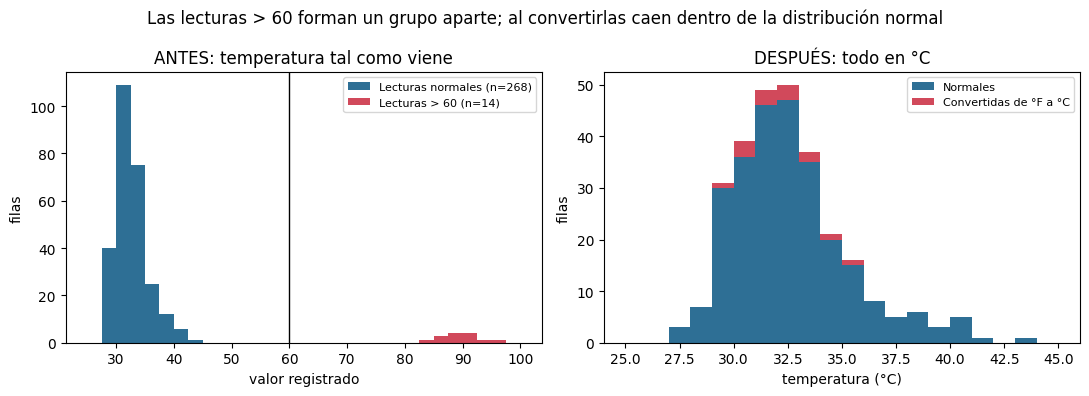

In [10]:
FIG = BASE / "figuras"; FIG.mkdir(exist_ok=True)
t_orig = pd.to_numeric(df.drop_duplicates()["temperatura"].astype(str).str.replace(",", ".", regex=False),
                       errors="coerce").dropna()
en_f = t_orig > SENSOR_MAX
conv_c = ((t_orig[en_f] - 32) * 5 / 9).round(1)
no_conv = t_orig[~en_f]
print(f"Sin convertir: n={len(no_conv)}, {no_conv.min():.1f}-{no_conv.max():.1f} °C | "
      f"> 60: n={int(en_f.sum())}, {t_orig[en_f].min():.1f}-{t_orig[en_f].max():.1f} | "
      f"en °C: {conv_c.min():.1f}-{conv_c.max():.1f} (dentro del rango normal: "
      f"{conv_c.between(no_conv.min(), no_conv.max()).all()})")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(no_conv, bins=np.arange(25, 101, 2.5), color="#2e6f95", label=f"Lecturas normales (n={len(no_conv)})")
ax[0].hist(t_orig[en_f], bins=np.arange(25, 101, 2.5), color="#d1495b", label=f"Lecturas > 60 (n={int(en_f.sum())})")
ax[0].axvline(SENSOR_MAX, color="black", lw=1)
ax[0].set(title="ANTES: temperatura tal como viene", xlabel="valor registrado", ylabel="filas"); ax[0].legend(fontsize=8)
ax[1].hist([no_conv, conv_c], bins=np.arange(25, 46, 1), stacked=True, color=["#2e6f95", "#d1495b"],
           label=["Normales", "Convertidas de °F a °C"])
ax[1].set(title="DESPUÉS: todo en °C", xlabel="temperatura (°C)", ylabel="filas"); ax[1].legend(fontsize=8)
fig.suptitle("Las lecturas > 60 forman un grupo aparte; al convertirlas caen dentro de la distribución normal")
fig.tight_layout(); fig.savefig(FIG / "hist_temperatura.png", dpi=130); plt.show()

## 4. Base de datos del ERD (SQLite)
Se crea la base con `schema.sql` (con reglas `CHECK` y `UNIQUE`) y se carga la tabla limpia. La base rechaza por sí sola los errores que arriba se limpiaron a mano.

In [11]:
DB = DATA / "planta.db"
if DB.exists():
    DB.unlink()
con = sqlite3.connect(DB)
con.executescript((BASE / "schema.sql").read_text(encoding="utf-8"))
con.executemany("INSERT INTO linea VALUES (?,?,?)", [(1, "Línea 1", "Película"), (2, "Línea 2", "Bolsas")])
con.executemany("INSERT INTO maquina VALUES (?,?,?,?)", [
    ("M-01", "Extrusora A", 1, 2019), ("M-02", "Extrusora B", 1, 2021),
    ("M-03", "Selladora C", 2, 2012), ("M-04", "Cortadora D", 2, 2023)])
con.executemany("INSERT INTO turno VALUES (?,?)", [(1, "Mañana"), (2, "Tarde"), (3, "Noche")])

id_turno = {"Mañana": 1, "Tarde": 2, "Noche": 3}
hechos = pd.DataFrame({
    "fecha": limpio["fecha"].dt.strftime("%Y-%m-%d"),
    "id_maquina": limpio["maquina"],
    "id_turno": limpio["turno"].map(id_turno),
    "producidas": limpio["producidas"], "defectuosas": limpio["defectuosas"],
    "temperatura_c": limpio["temperatura"], "temp_imputada": limpio["temp_imputada"].astype(int)})
hechos.to_sql("registro_produccion", con, if_exists="append", index=False)
con.commit()
print("Filas cargadas:", con.execute("SELECT COUNT(*) FROM registro_produccion").fetchone()[0])
print("Integridad referencial:", con.execute("PRAGMA foreign_key_check").fetchall() or "OK")

Filas cargadas: 271
Integridad referencial: OK


## 5. Pregunta 1 — ¿Qué máquinas superan la tasa de defectos de toda la planta?
*Filtro + agregación:* `GROUP BY` por máquina y `HAVING` contra la tasa global. La tasa se calcula con **totales** (no promediando tasas por fila: un turno grande pesa más que uno pequeño).

In [12]:
texto = (BASE / "consultas.sql").read_text(encoding="utf-8")
bloques = re.split(r"^-- \[(\w+)\]\s*$", texto, flags=re.M)[1:]
consultas = dict(zip(bloques[0::2], (b.strip() for b in bloques[1::2])))

p1_sql = pd.read_sql_query(consultas["P1"], con)
display(p1_sql)
print("Contexto, ranking completo de las 4 máquinas:")
display(pd.read_sql_query(consultas["P1_CONTEXTO"], con))

,id_maquina,nombre,producidas,defectuosas,tasa_pct,veces_la_planta
0,M-03,Selladora C,81008,3475,4.29,1.94


Contexto, ranking completo de las 4 máquinas:


,id_maquina,producidas,defectuosas,tasa_pct
0,M-03,81008,3475,4.29
1,M-01,80475,1389,1.73
2,M-02,81031,1302,1.61
3,M-04,80958,982,1.21


In [13]:
# Equivalente en pandas
d = hechos.merge(pd.DataFrame({"id_turno": [1, 2, 3], "turno": ["Mañana", "Tarde", "Noche"]}), on="id_turno")
tasa_planta = d["defectuosas"].sum() / d["producidas"].sum() * 100
por_maq = d.groupby("id_maquina").agg(producidas=("producidas", "sum"), defectuosas=("defectuosas", "sum"))
por_maq["tasa_pct"] = (por_maq["defectuosas"] / por_maq["producidas"] * 100).round(2)
p1_pd = por_maq[por_maq["defectuosas"] / por_maq["producidas"] * 100 > tasa_planta].sort_values("tasa_pct", ascending=False)
print(f"Tasa de toda la planta: {tasa_planta:.2f} %")
display(p1_pd)
assert list(p1_sql["id_maquina"]) == list(p1_pd.index) and list(p1_sql["tasa_pct"]) == list(p1_pd["tasa_pct"])
print("SQL y pandas coinciden.")

Tasa de toda la planta: 2.21 %


,producidas,defectuosas,tasa_pct
id_maquina,,,
M-03,81008,3475,4.29


SQL y pandas coinciden.


**Hallazgo.** Solo la **M-03** supera la tasa de la planta (4,29 % frente a 2,21 %, casi el doble). Las otras tres están entre 1,21 % y 1,73 %. Este resultado solo es confiable tras la limpieza: en el registro sin limpiar había 16 "máquinas" y, entre los códigos bien escritos, la M-01 aparecía con 5,93 % frente a 3,58 % de la M-03. Casi todo ese 5,93 % lo producen **3 filas con las columnas invertidas** (16 producidas y 959 defectuosas, etc.), todas de la M-01: sin ellas la M-01 queda en 1,62 %. Sin limpiar habríamos mandado a mantenimiento la máquina equivocada (la sección 7 repite este ejercicio con el resto de la limpieza ya hecha).

## 6. Pregunta 2 — En la M-03, ¿en qué turno se concentran los defectos y qué temperatura traía?
*Filtro + agregación:* `WHERE id_maquina = 'M-03'` y `GROUP BY` turno. La temperatura media usa solo lecturas **medidas** (se excluyen las imputadas).

In [14]:
p2_sql = pd.read_sql_query(consultas["P2"], con)
display(p2_sql)

,turno,registros,temp_media_c,producidas,defectuosas,tasa_pct
0,Tarde,23,38.5,26923,1736,6.45
1,Mañana,22,34.5,26683,925,3.47
2,Noche,22,30.7,27402,814,2.97


In [15]:
# Equivalente en pandas
m03 = d[d["id_maquina"] == "M-03"]
p2_pd = m03.groupby("turno").agg(
    registros=("producidas", "size"),
    temp_media_c=("temperatura_c", lambda s: round(s[m03.loc[s.index, "temp_imputada"] == 0].mean(), 1)),
    producidas=("producidas", "sum"), defectuosas=("defectuosas", "sum"))
p2_pd["tasa_pct"] = (p2_pd["defectuosas"] / p2_pd["producidas"] * 100).round(2)
p2_pd = p2_pd.sort_values("tasa_pct", ascending=False)
display(p2_pd)
assert list(p2_sql["turno"]) == list(p2_pd.index) and list(p2_sql["tasa_pct"]) == list(p2_pd["tasa_pct"])
print("SQL y pandas coinciden.\n")

# ¿La M-03 solo falla en la tarde? Tasa (%) por máquina y turno
g = d.groupby(["id_maquina", "turno"])[["producidas", "defectuosas"]].sum()
g["tasa_pct"] = (g["defectuosas"] / g["producidas"] * 100).round(2)
print("Tasa de defectos (%) por máquina y turno:")
display(g["tasa_pct"].unstack()[["Mañana", "Tarde", "Noche"]])
otras = d[d["id_maquina"] != "M-03"].groupby("turno")[["producidas", "defectuosas"]].sum()
print("Las otras 3 máquinas juntas:", (otras["defectuosas"] / otras["producidas"] * 100).round(2).to_dict())

# Correlación temperatura–tasa: global y DENTRO de cada turno, con valor p (solo lecturas medidas)
medidas = d[d["temp_imputada"] == 0].rename(columns={"id_maquina": "maquina", "temperatura_c": "temperatura"}).copy()
medidas["tasa"] = medidas["defectuosas"] / medidas["producidas"] * 100

def fila_corr(maquina, turno, x):
    r, p = stats.pearsonr(x["temperatura"], x["tasa"])
    rs, ps = stats.spearmanr(x["temperatura"], x["tasa"])
    return {"maquina": maquina, "turno": turno, "n": len(x), "pearson_r": round(r, 2),
            "p_pearson": float(f"{p:.3g}"), "spearman_r": round(rs, 2), "p_spearman": float(f"{ps:.3g}")}

filas = [fila_corr(m, "todos", medidas[medidas["maquina"] == m]) for m in ["M-01", "M-02", "M-03", "M-04"]]
filas += [fila_corr("M-03", t, medidas[(medidas["maquina"] == "M-03") & (medidas["turno"] == t)])
          for t in ["Mañana", "Tarde", "Noche"]]
corr = pd.DataFrame(filas)
display(corr)
corr.to_csv(DATA / "correlacion_temp_tasa.csv", index=False)

,registros,temp_media_c,producidas,defectuosas,tasa_pct
turno,,,,,
Tarde,23,38.5,26923,1736,6.45
Mañana,22,34.5,26683,925,3.47
Noche,22,30.7,27402,814,2.97


SQL y pandas coinciden.

Tasa de defectos (%) por máquina y turno:


turno,Mañana,Tarde,Noche
id_maquina,,,
M-01,1.76,1.69,1.73
M-02,1.65,1.51,1.66
M-03,3.47,6.45,2.97
M-04,1.32,1.15,1.17


Las otras 3 máquinas juntas: {'Mañana': 1.58, 'Noche': 1.51, 'Tarde': 1.46}


,maquina,turno,n,pearson_r,p_pearson,spearman_r,p_spearman
0,M-01,todos,64,-0.04,7.240000e-01,-0.12,3.390000e-01
1,M-02,todos,67,-0.25,3.910000e-02,-0.23,5.680000e-02
2,M-03,todos,67,0.81,1.010000e-16,0.74,9.350000e-13
3,M-04,todos,67,0.05,7.010000e-01,0.00,9.900000e-01
4,M-03,Mañana,22,0.69,3.940000e-04,0.41,5.690000e-02
5,M-03,Tarde,23,0.99,1.350000e-18,0.98,2.960000e-16
6,M-03,Noche,22,0.46,3.310000e-02,0.33,1.380000e-01


**Figura de apoyo.** Boxplot de temperatura por máquina y, para la M-03, temperatura contra tasa de defectos separando por turno.

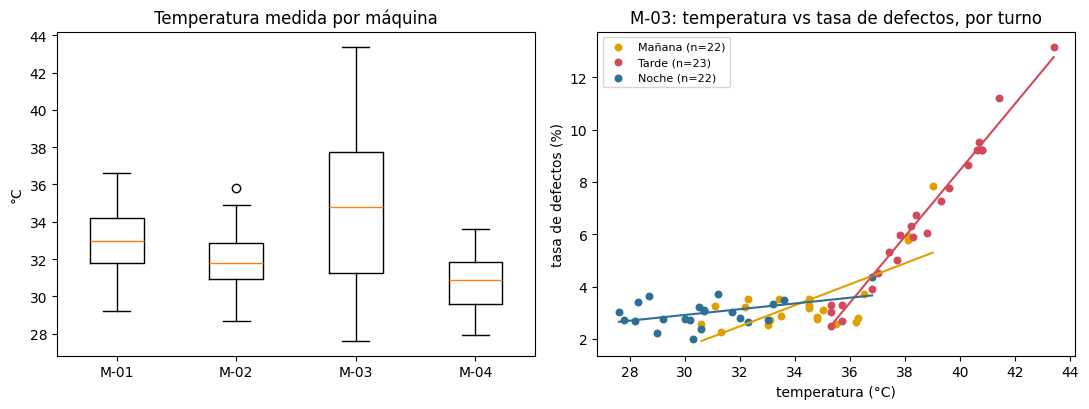

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
maqs = ["M-01", "M-02", "M-03", "M-04"]
ax[0].boxplot([medidas.loc[medidas["maquina"] == m, "temperatura"] for m in maqs]); ax[0].set_xticklabels(maqs)
ax[0].set(title="Temperatura medida por máquina", ylabel="°C")
color = {"Mañana": "#e0a100", "Tarde": "#d1495b", "Noche": "#2e6f95"}
s3 = medidas[medidas["maquina"] == "M-03"]
for t in ["Mañana", "Tarde", "Noche"]:
    s = s3[s3["turno"] == t]
    ax[1].scatter(s["temperatura"], s["tasa"], s=22, color=color[t], label=f"{t} (n={len(s)})")
    a, b = np.polyfit(s["temperatura"], s["tasa"], 1)
    xs = np.array([s["temperatura"].min(), s["temperatura"].max()])
    ax[1].plot(xs, a * xs + b, color=color[t], lw=1.5)
ax[1].set(title="M-03: temperatura vs tasa de defectos, por turno", xlabel="temperatura (°C)", ylabel="tasa de defectos (%)")
ax[1].legend(fontsize=8); fig.tight_layout(); fig.savefig(FIG / "temperatura_vs_defectos.png", dpi=130); plt.show()

**Hallazgo.** La M-03 está peor que las demás **en los tres turnos**: 3,47 % en la mañana, 2,97 % en la noche y 6,45 % en la tarde, contra 1,5–1,6 % de las otras tres máquinas juntas en cualquier turno. La **tarde agrava** un problema que la M-03 ya tiene; no lo origina. La tarde es también el turno más caliente de la M-03 (38,5 °C de media frente a 34,5 y 30,7), pero ojo: en la noche la M-03 trabaja a 30,7 °C, más fría que la M-01 (31,2 °C), y aun así tiene casi el doble de defectos. Es decir, **la temperatura no explica el exceso base de la M-03; solo parece explicar el empeoramiento de la tarde.**

**Sobre la correlación.** La r = 0,81 de la M-03 mezcla los tres turnos (la tarde es a la vez el más caliente y el de más defectos), así que se mira dentro de cada turno: r = 0,99 en la tarde (n = 23), 0,69 en la mañana (n = 22) y 0,46 en la noche (n = 22), todas con p < 0,05 en Pearson. Con Spearman (más robusto) solo la tarde sigue siendo clara (ρ = 0,98, p < 0,001; mañana ρ = 0,41, p = 0,057; noche ρ = 0,33, p = 0,138). En las otras máquinas no hay relación útil (M-01 −0,04; M-04 0,05; M-02 −0,25, débil y negativa, p = 0,039 sin corregir por pruebas múltiples). Correlación no es causalidad: una r de 0,99 en una muestra de 23 es una pista fuerte, no una prueba.

**Recomendación.** Inspeccionar la **M-03 primero y en general** (no solo su parte térmica: sigue con defectos altos de mañana y de noche) y, además, revisar su refrigeración en la tarde. Como la M-03 es la más antigua (2012), desgaste es una hipótesis razonable, pero habría que contrastarla con el historial de mantenimiento (entidad `MANTENIMIENTO` del ERD, sin datos en este dataset).

## 7. Sensibilidad: ¿cambia la conclusión según qué se haga con las 7 filas imposibles?
Eliminarlas fue una decisión conservadora. Para comprobar que no condiciona los resultados se comparan tres escenarios: **A** eliminarlas (la entrega), **B** corregirlas de forma casi determinista (invertir las 3 con columnas cambiadas, quitar el cero de más a las 2 sobre capacidad, valor absoluto a las 2 negativas) y **C** no filtrarlas, dejarlas tal cual.

In [17]:
cols = ["turno", "maquina", "producidas", "defectuosas"]
corregidas = descartadas.copy()
inv = corregidas["motivo"] == "columnas invertidas"
corregidas.loc[inv, ["producidas", "defectuosas"]] = corregidas.loc[inv, ["defectuosas", "producidas"]].values
sob = corregidas["motivo"] == "sobre capacidad"
corregidas.loc[sob, "producidas"] = corregidas.loc[sob, "producidas"] / 10
neg = corregidas["motivo"] == "defectuosas negativa"
corregidas.loc[neg, "defectuosas"] = corregidas.loc[neg, "defectuosas"].abs()
assert corregidas["producidas"].between(1, 1800).all() and corregidas["defectuosas"].between(0, corregidas["producidas"]).all()
corregidas["tasa_corregida_pct"] = (corregidas["defectuosas"] / corregidas["producidas"] * 100).round(2)
display(corregidas[["fecha", "maquina", "turno", "motivo", "producidas", "defectuosas", "tasa_corregida_pct"]])

escenarios = {"A. Eliminar las 7 (entrega)": limpio[cols],
              "B. Corregir las 7": pd.concat([limpio[cols], corregidas[cols]], ignore_index=True),
              "C. No filtrar (dejarlas tal cual)": pd.concat([limpio[cols], descartadas[cols]], ignore_index=True)}
resumen = []
for nombre, t in escenarios.items():
    pm = t.groupby("maquina")[["producidas", "defectuosas"]].sum()
    tasa = pm["defectuosas"] / pm["producidas"] * 100
    m3 = t[t["maquina"] == "M-03"].groupby("turno")[["producidas", "defectuosas"]].sum()
    tm3 = m3["defectuosas"] / m3["producidas"] * 100
    resumen.append({"escenario": nombre, "filas": len(t), **{f"tasa_{m}": round(tasa[m], 2) for m in tasa.index},
                    "maquina_mas_alta": tasa.idxmax(), "M-03_tarde": round(tm3["Tarde"], 2),
                    "M-03_mañana": round(tm3["Mañana"], 2), "M-03_noche": round(tm3["Noche"], 2),
                    "turno_mas_alto_M-03": tm3.idxmax()})
sens = pd.DataFrame(resumen)
display(sens)
sens.to_csv(DATA / "sensibilidad_imposibles.csv", index=False)

,fecha,maquina,turno,motivo,producidas,defectuosas,tasa_corregida_pct
42,2026-09-10,M-01,Noche,columnas invertidas,959,16.0,1.67
86,2026-09-15,M-02,Tarde,sobre capacidad,1132,16.0,1.41
128,2026-09-19,M-03,Mañana,defectuosas negativa,984,35.0,3.56
137,2026-09-21,M-01,Mañana,columnas invertidas,1303,25.0,1.92
167,2026-09-23,M-03,Tarde,defectuosas negativa,1299,67.0,5.16
170,2026-09-23,M-02,Noche,sobre capacidad,1077,19.0,1.76
228,2026-09-29,M-01,Noche,columnas invertidas,1295,18.0,1.39


,escenario,filas,tasa_M-01,tasa_M-02,tasa_M-03,tasa_M-04,maquina_mas_alta,M-03_tarde,M-03_mañana,M-03_noche,turno_mas_alto_M-03
0,A. Eliminar las 7 (entrega),271,1.73,1.61,4.29,1.21,M-03,6.45,3.47,2.97,Tarde
1,B. Corregir las 7,278,1.72,1.61,4.29,1.21,M-03,6.39,3.47,2.97,Tarde
2,C. No filtrar (dejarlas tal cual),278,6.14,1.30,4.05,1.21,M-01,5.91,3.22,2.97,Tarde


**Lectura.** En los escenarios **A** y **B** la respuesta es la misma: la M-03 es la peor máquina (4,29 %) y la tarde es su peor turno (6,45 % vs 6,39 %). Las tasas corregidas de las 7 filas quedan en rangos normales para su máquina (1,4–1,9 % en M-01 y M-02, 3,6–5,2 % en M-03), lo que hace plausible la corrección, pero no cambia nada, así que se mantiene la eliminación por prudencia. Solo el escenario **C** cambia el resultado: dejar las 3 filas invertidas lleva a la M-01 a 6,14 % y la hace parecer la peor máquina. Es decir, filtrar los imposibles **sí importa**, pero *cómo* se filtran (eliminar o corregir) no.

In [18]:
con.close()

## Referencias
[1] IBM, "¿Qué es el mantenimiento predictivo?," IBM Think, 2026. https://www.ibm.com/think/topics/predictive-maintenance  
[2] J. A. González Bonilla, "Taller en clase: Calidad de datos, diagnosticar, limpiar y medir," CORHUILA, Semana 9, Corte 2, 2026.  
[5] W. McKinney, "Data structures for statistical computing in Python," in *Proc. 9th Python in Science Conf. (SciPy)*, 2010, pp. 56–61.  
[6] C. Batini and M. Scannapieco, *Data and Information Quality*. Cham, Switzerland: Springer, 2016.  
(La lista completa está en el `README.md`.)